In [12]:
#imports
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chisquare

def df(file): 
    df = pd.read_csv(file)
    return df

In [13]:
#constants
distance_uncertainty = 0.2 #cm

field_names = ["Time (s)", " Geiger Counts (counts/sample)"]

runs = {
    "Distance_26.5cm": 26.5,
    "Distance_20.5cm": 20.5,
    "Distance_14.5cm": 14.5,
    "Distance_8.5cm": 8.5,
    "Distance_2.5cm": 2.5,
    "Distance_0cm": 0
}

noise_names = ["Background_Run1", "Background_Run2", "Background_Run3"]

histogram_data_names = [
    "Sampling_0_5Hz.csv",
    "Sampling_1Hz.csv",
    "Sampling_5Hz.csv",
    "Sampling_10Hz.csv",
    "Sampling_50Hz.csv",
    "Sampling_100Hz.csv",
]

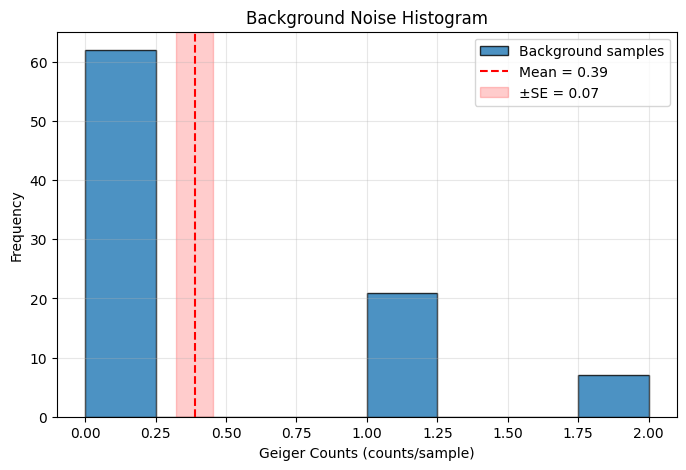

In [14]:
noices = []
for name in noise_names:
    data = df(f"noise/{name}.csv")[field_names[1]].to_numpy()
    avg_data = np.mean(data)
    noices.append(avg_data)

noise = np.average(noices)

noise_samples = np.concatenate(
    [df(f"noise/{n}.csv")[field_names[1]].to_numpy() for n in noise_names]
)

# Standard error of the mean (SEM)
noise_mean = noise_samples.mean()
noise_std = np.std(noise_samples, ddof=1)
noise_se = noise_std / np.sqrt(len(noise_samples))

plt.figure(figsize=(8, 5))
plt.hist(noise_samples, bins="auto", edgecolor="black", alpha=0.8, label="Background samples")
plt.axvline(noise_mean, color="red", linestyle="--", label=f"Mean = {noise_mean:.2f}")
plt.axvspan(noise_mean - noise_se, noise_mean + noise_se, color="red", alpha=0.2, label=f"±SE = {noise_se:.2f}")

plt.title("Background Noise Histogram")
plt.xlabel("Geiger Counts (counts/sample)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.legend()



plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


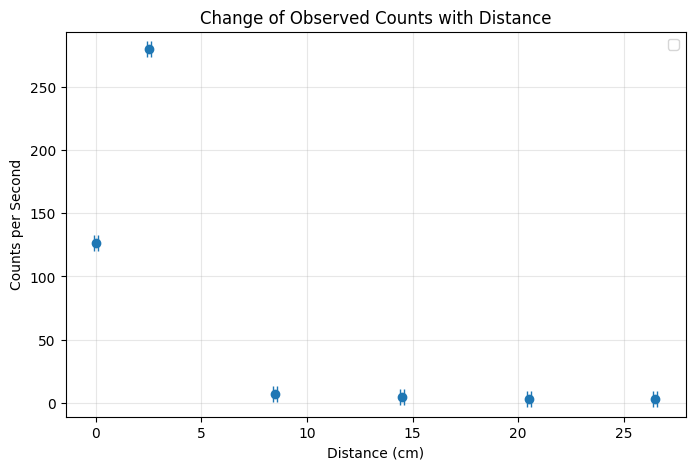

In [15]:
# Extract distances and average counts per second from the runs dict
distances = []
avg_counts = []

for key, dist in runs.items():
    data = df(f"length_data/{key}.csv")[" Geiger Counts (counts/sample)"].to_numpy()
    avg_val = np.mean(data)
    if dist == 2.5:
        avg_val *= 5 
    distances.append(dist)
    avg_counts.append(avg_val)

distances = np.array(distances)
avg_counts = np.array(avg_counts)

# Sort by distance
sort_idx = np.argsort(distances)
distances = distances[sort_idx]
avg_counts = avg_counts[sort_idx]

plt.figure(figsize=(8, 5))
plt.errorbar(distances, avg_counts, xerr=0.1, fmt='o', markersize=6, capsize=6,)
plt.xlabel("Distance (cm)")
plt.ylabel("Counts per Second")
plt.title("Change of Observed Counts with Distance")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [16]:
#equations

#Poisson distribution
def poisson(x, mew):
    eq = ((mew**x)* math.exp(-mew))/(math.gamma(x + 1))
    return eq

##gaussian distribution
def gausian(x, mew, sigma):
    eq = math.exp(-((x- mew)**2)/(2*(sigma**2)))/(math.sqrt(2*math.pi*(sigma**2)))
    return eq

In [17]:
'''from scipy.stats import iqr

for filename in histogram_data_names:
    data = df(f"sampling_tests/{filename}")[field_names[1]].to_numpy()
    plt.figure()
    
    mew = np.mean(data)
    sigma = np.std(data)
    
    # Freedman-Diaconis rule for bin width
    data_iqr = iqr(data)
    bin_width = 2 * data_iqr / (len(data) ** (1/3))
    if bin_width == 0:
        bin_width = 1  # fallback for zero IQR
    x_min = int(np.min(data))
    x_max = int(np.max(data))
    num_bins = max(1, int(np.ceil((x_max - x_min) / bin_width)))
    
    min_bins_required = 4
    if num_bins < min_bins_required:
        num_bins = min_bins_required
    
    obs_hist, bin_edges, _ = plt.hist(data, bins=num_bins, alpha=1, density=True, label="Histogram")
    
    x = np.arange(x_min, x_max + 1)

    x_smooth = np.linspace(x_min, x_max, 200)
    gauss_y_smooth = np.array([gausian(val, mew, sigma) for val in x_smooth])
    plt.plot(x_smooth, gauss_y_smooth, 'r-', label="Gaussian (normalized)")
    
    pois_y = np.array([poisson(val, mew) for val in x])
    plt.plot(x, pois_y, 'g--', label="Poisson (normalized)")
    
    obs_counts = np.array([np.sum(data == val) for val in x])
    
    exp_gauss = np.array([gausian(val, mew, sigma) for val in x])
    exp_gauss = exp_gauss / exp_gauss.sum() * obs_counts.sum()
    
    exp_pois = np.array([poisson(val, mew) for val in x])
    exp_pois = exp_pois / exp_pois.sum() * obs_counts.sum()
    
    def merge_small_bins(obs, exp, min_exp=5):
        obs_m, exp_m = [], []
        o_acc, e_acc = 0, 0
        for o, e in zip(obs, exp):
            o_acc += o
            e_acc += e
            if e_acc >= min_exp:
                obs_m.append(o_acc)
                exp_m.append(e_acc)
                o_acc, e_acc = 0, 0
        if e_acc > 0:
            if len(obs_m) > 0:
                obs_m[-1] += o_acc
                exp_m[-1] += e_acc
            else:
                obs_m.append(o_acc)
                exp_m.append(e_acc)
        return np.array(obs_m), np.array(exp_m)
    
    obs_g, exp_g = merge_small_bins(obs_counts, exp_gauss)
    obs_p, exp_p = merge_small_bins(obs_counts, exp_pois)
    
    k_g = len(obs_g)
    k_p = len(obs_p)
    dof_g = k_g - 1 - 2
    dof_p = k_p - 1 - 1
    
    if dof_g <= 0 or dof_p <= 0:
        num_bins = max(num_bins, x_max - x_min + 1)
        plt.clf()
        obs_hist, bin_edges, _ = plt.hist(data, bins=num_bins, alpha=1, density=True, label="Histogram")
        plt.plot(x_smooth, gauss_y_smooth, 'r-', label="Gaussian (normalized)")
        plt.plot(x, pois_y, 'g--', label="Poisson (normalized)")
        for min_exp_threshold in [5, 3, 1]:
            obs_g, exp_g = merge_small_bins(obs_counts, exp_gauss, min_exp=min_exp_threshold)
            obs_p, exp_p = merge_small_bins(obs_counts, exp_pois, min_exp=min_exp_threshold)
            k_g = len(obs_g)
            k_p = len(obs_p)
            dof_g = k_g - 1 - 2
            dof_p = k_p - 1 - 1
            if dof_g > 0 and dof_p > 0:
                break
    
    chi_gaussian = chisquare(obs_g, f_exp=exp_g, ddof=2)
    chi_poisson = chisquare(obs_p, f_exp=exp_p, ddof=1)
    
    red_chi_g = chi_gaussian.statistic / dof_g if dof_g > 0 else float('inf')
    red_chi_p = chi_poisson.statistic / dof_p if dof_p > 0 else float('inf')
    
    # Update legend labels with χ²/dof values
    ax = plt.gca()
    lines = ax.get_lines()
    for line in lines:
        lbl = line.get_label()
        if 'Gaussian' in lbl:
            line.set_label(f"Gaussian (χ²/dof={red_chi_g:.2f})")
        elif 'Poisson' in lbl:
            line.set_label(f"Poisson (χ²/dof={red_chi_p:.2f})")
    
    plt.title(f"Histogram with Gaussian & Poisson for {filename}")
    plt.xlabel("Geiger Counts (counts/sample)")
    plt.ylabel("Density")
    plt.grid()
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
'''

'from scipy.stats import iqr\n\nfor filename in histogram_data_names:\n    data = df(f"sampling_tests/{filename}")[field_names[1]].to_numpy()\n    plt.figure()\n\n    mew = np.mean(data)\n    sigma = np.std(data)\n\n    # Freedman-Diaconis rule for bin width\n    data_iqr = iqr(data)\n    bin_width = 2 * data_iqr / (len(data) ** (1/3))\n    if bin_width == 0:\n        bin_width = 1  # fallback for zero IQR\n    x_min = int(np.min(data))\n    x_max = int(np.max(data))\n    num_bins = max(1, int(np.ceil((x_max - x_min) / bin_width)))\n\n    min_bins_required = 4\n    if num_bins < min_bins_required:\n        num_bins = min_bins_required\n\n    obs_hist, bin_edges, _ = plt.hist(data, bins=num_bins, alpha=1, density=True, label="Histogram")\n\n    x = np.arange(x_min, x_max + 1)\n\n    x_smooth = np.linspace(x_min, x_max, 200)\n    gauss_y_smooth = np.array([gausian(val, mew, sigma) for val in x_smooth])\n    plt.plot(x_smooth, gauss_y_smooth, \'r-\', label="Gaussian (normalized)")\n\n    

1Hz: 3.572706354023478%
1Hz - Mean: 191.4833 ± 2.6705 (incl. noise SE=0.0665)
1Hz - Corrected mean (noise subtracted): 191.0944 ± 2.6705
1Hz - Gaussian fit R^2: 0.342
1Hz - Poisson fit R^2: 0.337
1Hz - Chi-square Gaussian: stat=15.264, dof=8, p=0.054, χ²/dof=1.908
1Hz - Chi-square Poisson: stat=8.737, dof=8, p=0.365, χ²/dof=1.092
1Hz - Merge small bins: ON
1Hz - Number of histogram bins (Freedman-Diaconis): 12
1Hz - Better fit: Poisson


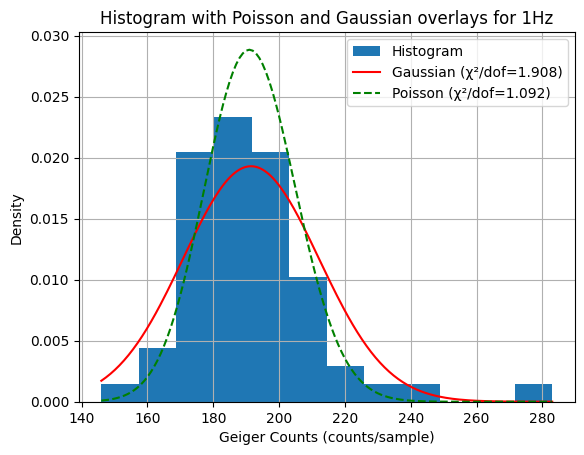

5Hz: -1.4343233164861617%
5Hz - Mean: 14.9670 ± 0.2202 (incl. noise SE=0.0665)
5Hz - Corrected mean (noise subtracted): 14.5781 ± 0.2202
5Hz - Gaussian fit R^2: 0.894
5Hz - Poisson fit R^2: 0.914
5Hz - Chi-square Gaussian: stat=11.941, dof=13, p=0.532, χ²/dof=0.919
5Hz - Chi-square Poisson: stat=9.559, dof=14, p=0.794, χ²/dof=0.683
5Hz - Merge small bins: ON
5Hz - Number of histogram bins (Freedman-Diaconis): 11
5Hz - Better fit: Poisson


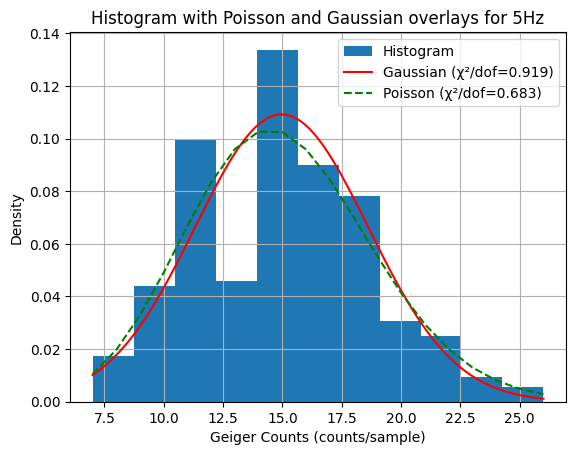

10Hz: -2.0288046019973307%
10Hz - Mean: 7.3185 ± 0.1233 (incl. noise SE=0.0665)
10Hz - Corrected mean (noise subtracted): 6.9296 ± 0.1233
10Hz - Gaussian fit R^2: 0.977
10Hz - Poisson fit R^2: 0.962
10Hz - Chi-square Gaussian: stat=16.774, dof=9, p=0.052, χ²/dof=1.864
10Hz - Chi-square Poisson: stat=12.022, dof=11, p=0.362, χ²/dof=1.093
10Hz - Merge small bins: ON
10Hz - Number of histogram bins (Freedman-Diaconis): 22
10Hz - Better fit: Poisson


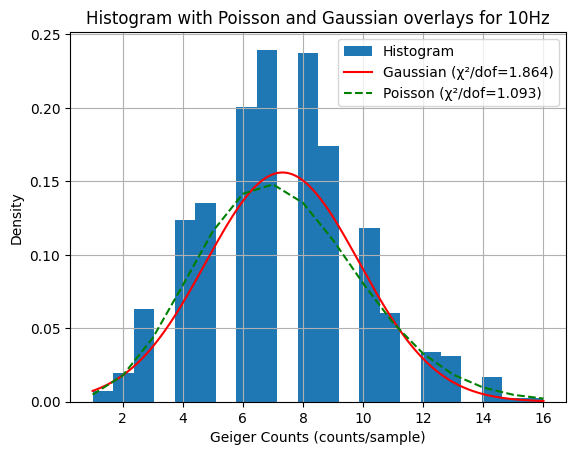

25Hz: -2.4623994414923045%
25Hz - Mean: 2.9081 ± 0.0786 (incl. noise SE=0.0665)
25Hz - Corrected mean (noise subtracted): 2.5192 ± 0.0786
25Hz - Gaussian fit R^2: 0.969
25Hz - Poisson fit R^2: 0.991
25Hz - Chi-square Gaussian: stat=38.969, dof=5, p=0.000, χ²/dof=7.794
25Hz - Chi-square Poisson: stat=8.831, dof=7, p=0.265, χ²/dof=1.262
25Hz - Merge small bins: ON
25Hz - Number of histogram bins (Freedman-Diaconis): 29
25Hz - Better fit: Poisson


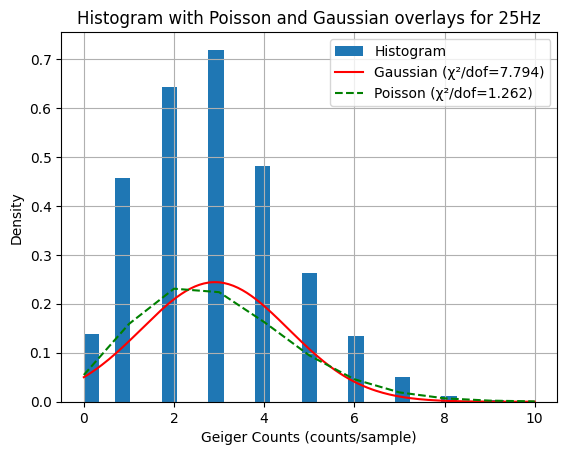

40Hz: -1.1780073941289726%
40Hz - Mean: 2.1549 ± 0.0726 (incl. noise SE=0.0665)
40Hz - Corrected mean (noise subtracted): 1.7661 ± 0.0726
40Hz - Gaussian fit R^2: 0.959
40Hz - Poisson fit R^2: 0.997
40Hz - Chi-square Gaussian: stat=99.830, dof=4, p=0.000, χ²/dof=24.958
40Hz - Chi-square Poisson: stat=5.097, dof=6, p=0.531, χ²/dof=0.850
40Hz - Merge small bins: ON
40Hz - Number of histogram bins (Freedman-Diaconis): 27
40Hz - Better fit: Poisson


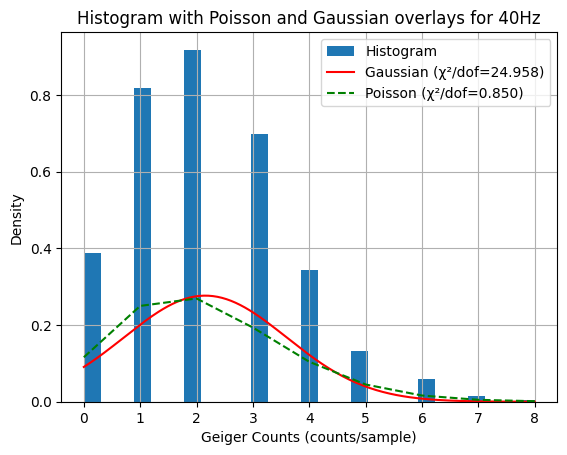

50Hz: -2.28852238763849%
50Hz - Mean: 1.7579 ± 0.0705 (incl. noise SE=0.0665)
50Hz - Corrected mean (noise subtracted): 1.3690 ± 0.0705
50Hz - Gaussian fit R^2: 0.943
50Hz - Poisson fit R^2: 0.996
50Hz - Chi-square Gaussian: stat=131.513, dof=3, p=0.000, χ²/dof=43.838
50Hz - Chi-square Poisson: stat=6.949, dof=6, p=0.326, χ²/dof=1.158
50Hz - Merge small bins: ON
50Hz - Number of histogram bins (Freedman-Diaconis): 26
50Hz - Better fit: Poisson


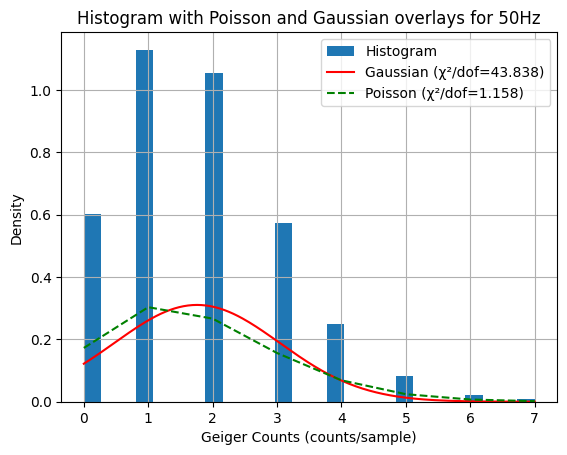

In [18]:
from scipy.special import gammaln

#some_more = ["Data_5Hz_1min_2.5cm.csv","test_5Hz_1min.csv"]
some_more = ["test_1Hz_1min_closer.csv","test_5Hz_1min.csv","test_10Hz_1min.csv", "test_25Hz_1min.csv", "test_40Hz_1min.csv", "test_50Hz_1min.csv"] 
labels = ["1Hz", "5Hz", "10Hz", "25Hz", "40Hz", "50Hz"]
merge_small = True  # Set to False to disable merging of small bins

for filename, label in zip(some_more, labels):
    data = df(f"data/{filename}")[field_names[1]].to_numpy()
    quarter_len = len(data)
    data = data[:quarter_len]
    
    # Subtract noise mean and propagate noise standard error
    data_corrected = data - noise_mean
    plt.figure()
    
    mew = np.mean(data)
    sigma = np.std(data)
    
    # Propagate noise_se into the uncertainty of the mean
    mew_corrected = mew - noise_mean
    sigma_mew = np.sqrt((sigma / np.sqrt(len(data)))**2 + noise_se**2)
    
    difference = -np.sqrt(mew) + sigma
    difference_percent = (difference / mew) * 100
    print(f"{label}: {difference_percent}%")
    print(f"{label} - Mean: {mew:.4f} ± {sigma_mew:.4f} (incl. noise SE={noise_se:.4f})")
    print(f"{label} - Corrected mean (noise subtracted): {mew_corrected:.4f} ± {sigma_mew:.4f}")
    
    # Use integer bins for discrete data
    x_min = int(np.min(data))
    x_max = int(np.max(data))
    bins = np.arange(x_min, x_max + 2) - 0.5  # center bins on integers
    
    # Freedman-Diaconis rule for number of bins
    data_iqr = np.subtract(*np.percentile(data, [75, 25]))
    n = len(data)
    if data_iqr > 0:
        bin_width_fd = 2 * data_iqr * n ** (-1/3)
        num_bins = max(4, int(np.ceil((data.max() - data.min()) / bin_width_fd)))
    else:
        num_bins = 4
    
    plt.hist(data, bins=num_bins, alpha=1, density=True, label="Histogram")
    
    x = np.arange(x_min, x_max + 1)

    # Gaussian plot
    x_smooth = np.linspace(x_min, x_max, 200)
    gauss_y_smooth = np.array([gausian(val, mew, sigma) for val in x_smooth])
    plt.plot(x_smooth, gauss_y_smooth, 'r-', label="Gaussian (normalized)")
    
    # Poisson plot - use log-space to avoid overflow with large values
    def poisson_safe(x, mu):
        return np.exp(x * np.log(mu) - mu - gammaln(x + 1))
    
    pois_y = np.array([poisson_safe(val, mew) for val in x])
    plt.plot(x, pois_y, 'g--', label="Poisson (normalized)")
    
    # Observed counts per integer value
    obs_counts = np.array([np.sum(data == val) for val in x])
    
    # Expected counts
    exp_gauss = np.array([gausian(val, mew, sigma) for val in x])
    exp_gauss = exp_gauss / exp_gauss.sum() * obs_counts.sum()
    
    exp_pois = np.array([poisson_safe(val, mew) for val in x])
    exp_pois = exp_pois / exp_pois.sum() * obs_counts.sum()
    
    # Merge bins with expected < 5 (chi-square requirement)
    def merge_small_bins(obs, exp, min_exp=5):
        obs_m, exp_m = [], []
        o_acc, e_acc = 0, 0
        for o, e in zip(obs, exp):
            o_acc += o
            e_acc += e
            if e_acc >= min_exp:
                obs_m.append(o_acc)
                exp_m.append(e_acc)
                o_acc, e_acc = 0, 0
        if e_acc > 0:
            obs_m[-1] += o_acc
            exp_m[-1] += e_acc
        return np.array(obs_m), np.array(exp_m)
    
    if merge_small:
        obs_g, exp_g = merge_small_bins(obs_counts, exp_gauss)
        obs_p, exp_p = merge_small_bins(obs_counts, exp_pois)
    else:
        obs_g, exp_g = obs_counts, exp_gauss
        obs_p, exp_p = obs_counts, exp_pois
    
    # R^2 values
    hist_vals = obs_counts / (obs_counts.sum())
    gauss_fit_vals = exp_gauss / exp_gauss.sum()
    pois_fit_vals = exp_pois / exp_pois.sum()
    
    ss_tot = np.sum((hist_vals - np.mean(hist_vals)) ** 2)
    r2 = 1 - np.sum((hist_vals - gauss_fit_vals) ** 2) / ss_tot
    r2_pois = 1 - np.sum((hist_vals - pois_fit_vals) ** 2) / ss_tot
    print(f"{label} - Gaussian fit R^2: {r2:.3f}")
    print(f"{label} - Poisson fit R^2: {r2_pois:.3f}")
    
    # ddof: 1 for Poisson (estimated mu), 2 for Gaussian (estimated mu, sigma)
    chi_gaussian = chisquare(obs_g, f_exp=exp_g, ddof=2)
    chi_poisson = chisquare(obs_p, f_exp=exp_p, ddof=1)
    
    dof_g = len(obs_g) - 1 - 2  # number of bins - 1 - estimated params
    dof_p = len(obs_p) - 1 - 1
    red_chi_g = chi_gaussian.statistic / dof_g if dof_g > 0 else float('inf')
    red_chi_p = chi_poisson.statistic / dof_p if dof_p > 0 else float('inf')
    
    print(f"{label} - Chi-square Gaussian: stat={chi_gaussian.statistic:.3f}, dof={dof_g}, p={chi_gaussian.pvalue:.3f}, χ²/dof={red_chi_g:.3f}")
    print(f"{label} - Chi-square Poisson: stat={chi_poisson.statistic:.3f}, dof={dof_p}, p={chi_poisson.pvalue:.3f}, χ²/dof={red_chi_p:.3f}")
    print(f"{label} - Merge small bins: {'ON' if merge_small else 'OFF'}")
    print(f"{label} - Number of histogram bins (Freedman-Diaconis): {num_bins}")
    print(f"{label} - Better fit:", "Poisson" if chi_poisson.statistic < chi_gaussian.statistic else "Gaussian")
    
    plt.title(f"Histogram with Poisson and Gaussian overlays for {label}")
    plt.xlabel("Geiger Counts (counts/sample)")
    plt.ylabel("Density")
    plt.grid()
    
    # Update legend labels with chi²/dof values
    ax = plt.gca()
    handles, labels_list = ax.get_legend_handles_labels()
    new_labels = []
    for lbl in labels_list:
        if lbl == "Gaussian (normalized)":
            new_labels.append(f"Gaussian (χ²/dof={red_chi_g:.3f})")
        elif lbl == "Poisson (normalized)":
            new_labels.append(f"Poisson (χ²/dof={red_chi_p:.3f})")
        else:
            new_labels.append(lbl)
    plt.legend(handles, new_labels)
    plt.show()

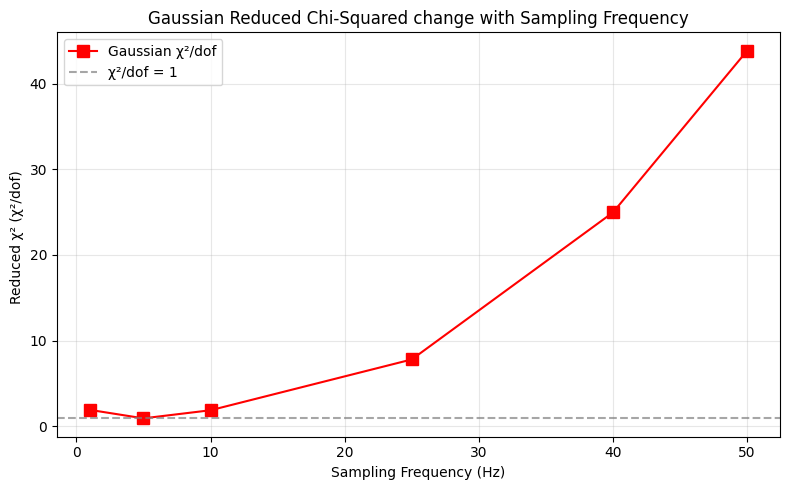

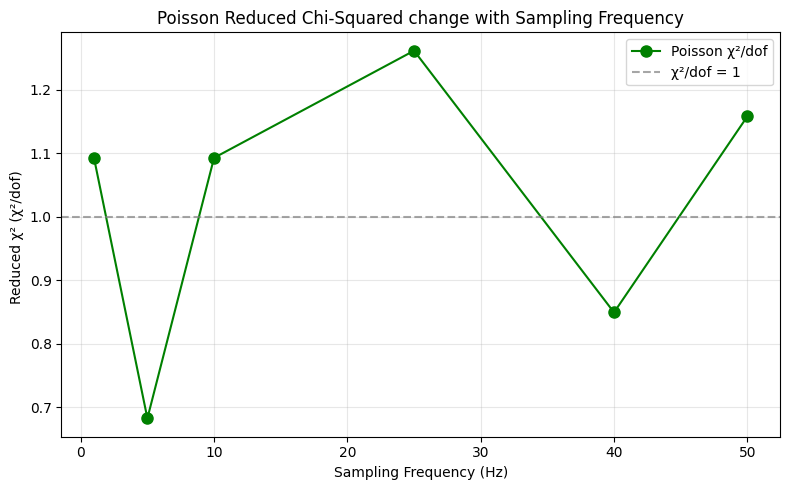

In [19]:
# Extract the sampling frequencies and chi²/dof values from cell 6 results
hz_values = [1, 5, 10, 25, 40, 50]

red_chi_g_list = []
red_chi_p_list = []

for filename, label in zip(some_more, labels):
    data_tmp = df(f"data/{filename}")[field_names[1]].to_numpy()
    
    mew_tmp = np.mean(data_tmp)
    sigma_tmp = np.std(data_tmp)
    
    x_min_tmp = int(np.min(data_tmp))
    x_max_tmp = int(np.max(data_tmp))
    
    x_tmp = np.arange(x_min_tmp, x_max_tmp + 1)
    
    obs_counts_tmp = np.array([np.sum(data_tmp == val) for val in x_tmp])
    
    exp_gauss_tmp = np.array([gausian(val, mew_tmp, sigma_tmp) for val in x_tmp])
    exp_gauss_tmp = exp_gauss_tmp / exp_gauss_tmp.sum() * obs_counts_tmp.sum()
    
    def poisson_safe_tmp(x_val, mu):
        return np.exp(x_val * np.log(mu) - mu - gammaln(x_val + 1))
    
    exp_pois_tmp = np.array([poisson_safe_tmp(val, mew_tmp) for val in x_tmp])
    exp_pois_tmp = exp_pois_tmp / exp_pois_tmp.sum() * obs_counts_tmp.sum()
    
    def merge_small_bins_tmp(obs, exp, min_exp=5):
        obs_m, exp_m = [], []
        o_acc, e_acc = 0, 0
        for o, e in zip(obs, exp):
            o_acc += o
            e_acc += e
            if e_acc >= min_exp:
                obs_m.append(o_acc)
                exp_m.append(e_acc)
                o_acc, e_acc = 0, 0
        if e_acc > 0:
            obs_m[-1] += o_acc
            exp_m[-1] += e_acc
        return np.array(obs_m), np.array(exp_m)
    
    obs_g_tmp, exp_g_tmp = merge_small_bins_tmp(obs_counts_tmp, exp_gauss_tmp)
    obs_p_tmp, exp_p_tmp = merge_small_bins_tmp(obs_counts_tmp, exp_pois_tmp)
    
    chi_g_tmp = chisquare(obs_g_tmp, f_exp=exp_g_tmp, ddof=2)
    chi_p_tmp = chisquare(obs_p_tmp, f_exp=exp_p_tmp, ddof=1)
    
    dof_g_tmp = len(obs_g_tmp) - 1 - 2
    dof_p_tmp = len(obs_p_tmp) - 1 - 1
    
    red_chi_g_list.append(chi_g_tmp.statistic / dof_g_tmp if dof_g_tmp > 0 else float('inf'))
    red_chi_p_list.append(chi_p_tmp.statistic / dof_p_tmp if dof_p_tmp > 0 else float('inf'))

# Plot 1: Gaussian chi²/dof
fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(hz_values, red_chi_g_list, 'rs-', markersize=8, label="Gaussian χ²/dof")
ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.7, label="χ²/dof = 1")
ax1.set_xlabel("Sampling Frequency (Hz)")
ax1.set_ylabel("Reduced χ² (χ²/dof) ")
ax1.set_title("Gaussian Reduced Chi-Squared change with Sampling Frequency")
ax1.grid(alpha=0.3)
ax1.legend()
plt.tight_layout()
plt.show()

# Plot 2: Poisson chi²/dof
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(hz_values, red_chi_p_list, 'go-', markersize=8, label="Poisson χ²/dof")
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.7, label="χ²/dof = 1")
ax2.set_xlabel("Sampling Frequency (Hz)")
ax2.set_ylabel("Reduced χ² (χ²/dof) ")
ax2.set_title("Poisson Reduced Chi-Squared change with Sampling Frequency")
ax2.grid(alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()

run 1: -1.4343233164861617%
run 1 - Mean: 14.9670 ± 0.2202 (incl. noise SE=0.0665)
run 1 - Corrected mean (noise subtracted): 14.5781 ± 0.2202
run 1 - Gaussian fit R^2: 0.894
run 1 - Poisson fit R^2: 0.914
run 1 - Chi-square Gaussian: stat=11.941, dof=13, p=0.532, χ²/dof=0.919
run 1 - Chi-square Poisson: stat=9.559, dof=14, p=0.794, χ²/dof=0.683
run 1 - Merge small bins: ON
run 1 - Number of histogram bins (Freedman-Diaconis): 11
run 1 - Better fit: Poisson


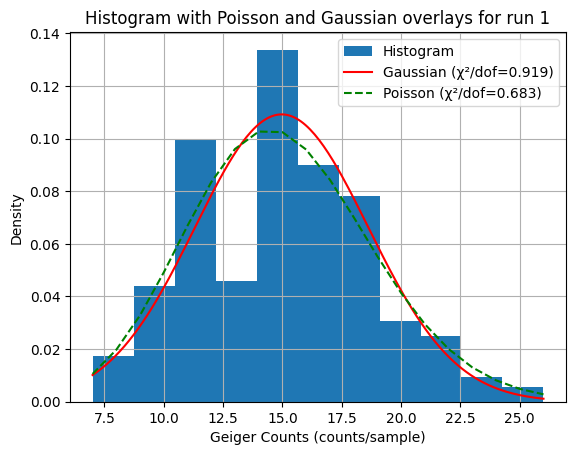

run 2: -2.1104749238663185%
run 2 - Mean: 22.8212 ± 0.2560 (incl. noise SE=0.0665)
run 2 - Corrected mean (noise subtracted): 22.4323 ± 0.2560
run 2 - Gaussian fit R^2: 0.890
run 2 - Poisson fit R^2: 0.877
run 2 - Chi-square Gaussian: stat=17.563, dof=15, p=0.286, χ²/dof=1.171
run 2 - Chi-square Poisson: stat=19.859, dof=17, p=0.282, χ²/dof=1.168
run 2 - Merge small bins: ON
run 2 - Number of histogram bins (Freedman-Diaconis): 15
run 2 - Better fit: Gaussian


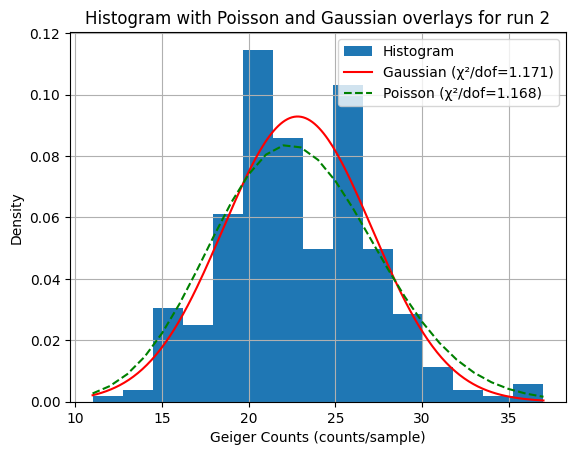

run 3: -1.9914335194461534%
run 3 - Mean: 23.2883 ± 0.3481 (incl. noise SE=0.0665)
run 3 - Corrected mean (noise subtracted): 22.8995 ± 0.3481
run 3 - Gaussian fit R^2: 0.873
run 3 - Poisson fit R^2: 0.862
run 3 - Chi-square Gaussian: stat=12.097, dof=12, p=0.438, χ²/dof=1.008
run 3 - Chi-square Poisson: stat=14.360, dof=14, p=0.423, χ²/dof=1.026
run 3 - Merge small bins: ON
run 3 - Number of histogram bins (Freedman-Diaconis): 13
run 3 - Better fit: Gaussian


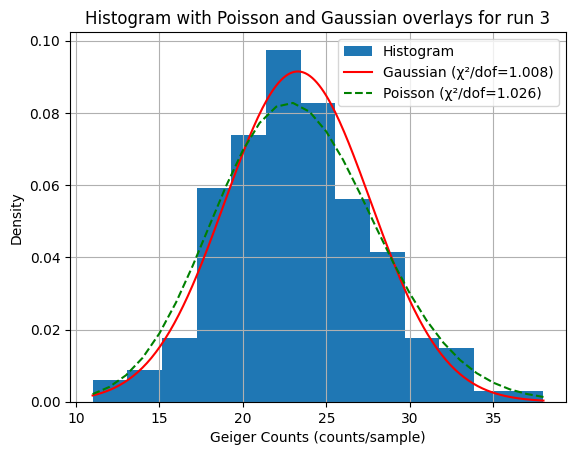

run 4: 0.18889471559655371%
run 4 - Mean: 23.1897 ± 0.3743 (incl. noise SE=0.0665)
run 4 - Corrected mean (noise subtracted): 22.8008 ± 0.3743
run 4 - Gaussian fit R^2: 0.785
run 4 - Poisson fit R^2: 0.794
run 4 - Chi-square Gaussian: stat=18.916, dof=14, p=0.168, χ²/dof=1.351
run 4 - Chi-square Poisson: stat=18.422, dof=15, p=0.241, χ²/dof=1.228
run 4 - Merge small bins: ON
run 4 - Number of histogram bins (Freedman-Diaconis): 11
run 4 - Better fit: Poisson


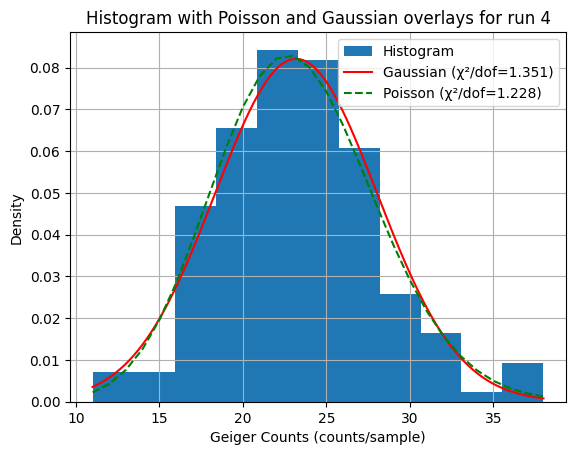

run 5: -1.1752193812502054%
run 5 - Mean: 23.0265 ± 0.2689 (incl. noise SE=0.0665)
run 5 - Corrected mean (noise subtracted): 22.6376 ± 0.2689
run 5 - Gaussian fit R^2: 0.938
run 5 - Poisson fit R^2: 0.935
run 5 - Chi-square Gaussian: stat=14.190, dof=16, p=0.585, χ²/dof=0.887
run 5 - Chi-square Poisson: stat=12.016, dof=18, p=0.846, χ²/dof=0.668
run 5 - Merge small bins: ON
run 5 - Number of histogram bins (Freedman-Diaconis): 16
run 5 - Better fit: Poisson


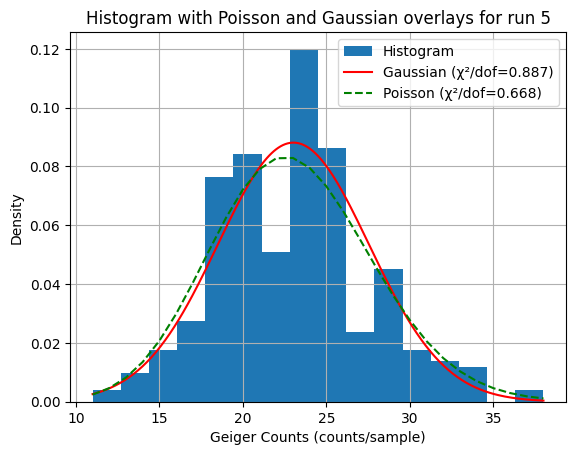

run 6: 0.18868003331502708%
run 6 - Mean: 23.3418 ± 0.3935 (incl. noise SE=0.0665)
run 6 - Corrected mean (noise subtracted): 22.9529 ± 0.3935
run 6 - Gaussian fit R^2: 0.772
run 6 - Poisson fit R^2: 0.780
run 6 - Chi-square Gaussian: stat=19.117, dof=14, p=0.161, χ²/dof=1.366
run 6 - Chi-square Poisson: stat=14.222, dof=14, p=0.433, χ²/dof=1.016
run 6 - Merge small bins: ON
run 6 - Number of histogram bins (Freedman-Diaconis): 13
run 6 - Better fit: Poisson


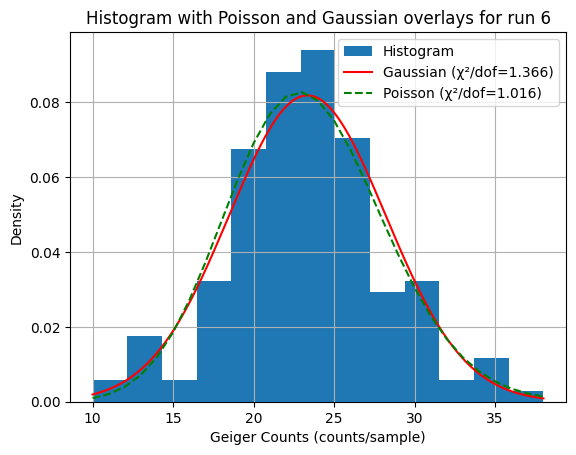

run 7: -0.2505093108698025%
run 7 - Mean: 23.4686 ± 0.2828 (incl. noise SE=0.0665)
run 7 - Corrected mean (noise subtracted): 23.0798 ± 0.2828
run 7 - Gaussian fit R^2: 0.854
run 7 - Poisson fit R^2: 0.860
run 7 - Chi-square Gaussian: stat=22.677, dof=17, p=0.160, χ²/dof=1.334
run 7 - Chi-square Poisson: stat=22.423, dof=18, p=0.214, χ²/dof=1.246
run 7 - Merge small bins: ON
run 7 - Number of histogram bins (Freedman-Diaconis): 14
run 7 - Better fit: Poisson


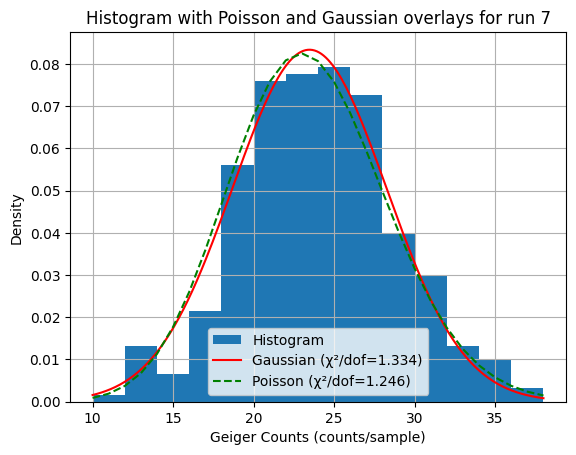

run 8: -1.7003294034599203%
run 8 - Mean: 22.9760 ± 0.3994 (incl. noise SE=0.0665)
run 8 - Corrected mean (noise subtracted): 22.5871 ± 0.3994
run 8 - Gaussian fit R^2: 0.759
run 8 - Poisson fit R^2: 0.752
run 8 - Chi-square Gaussian: stat=7.863, dof=11, p=0.726, χ²/dof=0.715
run 8 - Chi-square Poisson: stat=10.800, dof=13, p=0.628, χ²/dof=0.831
run 8 - Merge small bins: ON
run 8 - Number of histogram bins (Freedman-Diaconis): 10
run 8 - Better fit: Gaussian


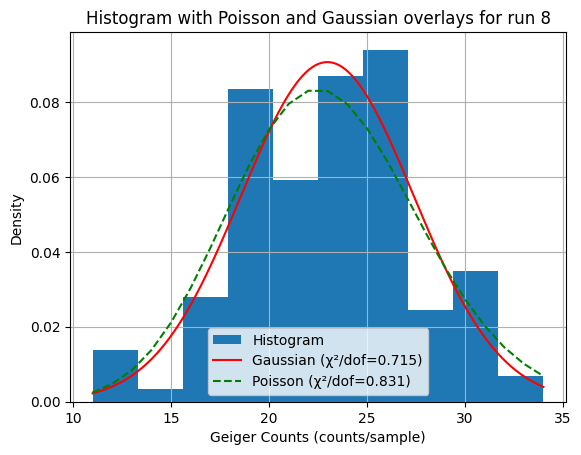

run 9: 2.2635398743666464%
run 9 - Mean: 22.8288 ± 0.5069 (incl. noise SE=0.0665)
run 9 - Corrected mean (noise subtracted): 22.4399 ± 0.5069
run 9 - Gaussian fit R^2: 0.672
run 9 - Poisson fit R^2: 0.643
run 9 - Chi-square Gaussian: stat=16.198, dof=12, p=0.182, χ²/dof=1.350
run 9 - Chi-square Poisson: stat=11.698, dof=12, p=0.470, χ²/dof=0.975
run 9 - Merge small bins: ON
run 9 - Number of histogram bins (Freedman-Diaconis): 10
run 9 - Better fit: Poisson


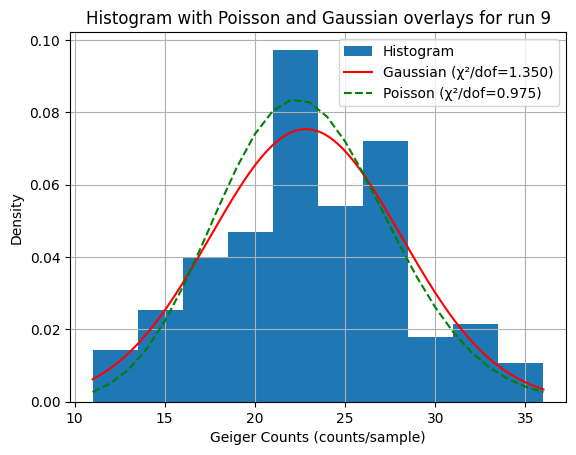

run 10: 0.053752176362462836%
run 10 - Mean: 22.7591 ± 0.2827 (incl. noise SE=0.0665)
run 10 - Corrected mean (noise subtracted): 22.3702 ± 0.2827
run 10 - Gaussian fit R^2: 0.863
run 10 - Poisson fit R^2: 0.858
run 10 - Chi-square Gaussian: stat=17.550, dof=16, p=0.351, χ²/dof=1.097
run 10 - Chi-square Poisson: stat=19.652, dof=17, p=0.292, χ²/dof=1.156
run 10 - Merge small bins: ON
run 10 - Number of histogram bins (Freedman-Diaconis): 14
run 10 - Better fit: Gaussian


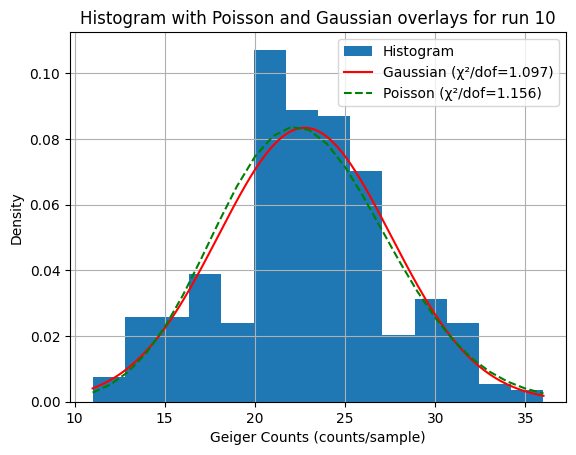

In [32]:
from scipy.special import gammaln

#some_more = ["Data_5Hz_1min_2.5cm.csv","test_5Hz_1min.csv"]
some_more = [
    "5Hz_Run1.csv",
    "5Hz_Run2.csv",
    "5Hz_run3.csv",
    "5Hz_Run4.csv",
    "5Hz_Run5.csv",
    "5Hz_Run6.csv",
    "5Hz_Run7.csv",
    "5Hz_Run8.csv",
    "5Hz_Run9.csv",
    "5Hz_Run10.csv",
]
labels = ["run 1", "run 2", "run 3", "run 4", "run 5", "run 6", "run 7", "run 8", "run 9", "run 10"]
merge_small = True  # Set to False to disable merging of small bins

for filename, label in zip(some_more, labels):
    data = df(f"data_5hz/{filename}")[field_names[1]].to_numpy()
    quarter_len = len(data)
    data = data[:quarter_len]
    
    # Subtract noise mean and propagate noise standard error
    data_corrected = data - noise_mean
    plt.figure()
    
    mew = np.mean(data)
    sigma = np.std(data)
    
    # Propagate noise_se into the uncertainty of the mean
    mew_corrected = mew - noise_mean
    sigma_mew = np.sqrt((sigma / np.sqrt(len(data)))**2 + noise_se**2)
    
    difference = -np.sqrt(mew) + sigma
    difference_percent = (difference / mew) * 100
    print(f"{label}: {difference_percent}%")
    print(f"{label} - Mean: {mew:.4f} ± {sigma_mew:.4f} (incl. noise SE={noise_se:.4f})")
    print(f"{label} - Corrected mean (noise subtracted): {mew_corrected:.4f} ± {sigma_mew:.4f}")
    
    # Use integer bins for discrete data
    x_min = int(np.min(data))
    x_max = int(np.max(data))
    bins = np.arange(x_min, x_max + 2) - 0.5  # center bins on integers
    
    # Freedman-Diaconis rule for number of bins
    data_iqr = np.subtract(*np.percentile(data, [75, 25]))
    n = len(data)
    if data_iqr > 0:
        bin_width_fd = 2 * data_iqr * n ** (-1/3)
        num_bins = max(4, int(np.ceil((data.max() - data.min()) / bin_width_fd)))
    else:
        num_bins = 4
    
    plt.hist(data, bins=num_bins, alpha=1, density=True, label="Histogram")
    
    x = np.arange(x_min, x_max + 1)

    # Gaussian plot
    x_smooth = np.linspace(x_min, x_max, 200)
    gauss_y_smooth = np.array([gausian(val, mew, sigma) for val in x_smooth])
    plt.plot(x_smooth, gauss_y_smooth, 'r-', label="Gaussian (normalized)")
    
    # Poisson plot - use log-space to avoid overflow with large values
    def poisson_safe(x, mu):
        return np.exp(x * np.log(mu) - mu - gammaln(x + 1))
    
    pois_y = np.array([poisson_safe(val, mew) for val in x])
    plt.plot(x, pois_y, 'g--', label="Poisson (normalized)")
    
    # Observed counts per integer value
    obs_counts = np.array([np.sum(data == val) for val in x])
    
    # Expected counts
    exp_gauss = np.array([gausian(val, mew, sigma) for val in x])
    exp_gauss = exp_gauss / exp_gauss.sum() * obs_counts.sum()
    
    exp_pois = np.array([poisson_safe(val, mew) for val in x])
    exp_pois = exp_pois / exp_pois.sum() * obs_counts.sum()
    
    # Merge bins with expected < 5 (chi-square requirement)
    def merge_small_bins(obs, exp, min_exp=5):
        obs_m, exp_m = [], []
        o_acc, e_acc = 0, 0
        for o, e in zip(obs, exp):
            o_acc += o
            e_acc += e
            if e_acc >= min_exp:
                obs_m.append(o_acc)
                exp_m.append(e_acc)
                o_acc, e_acc = 0, 0
        if e_acc > 0:
            obs_m[-1] += o_acc
            exp_m[-1] += e_acc
        return np.array(obs_m), np.array(exp_m)
    
    if merge_small:
        obs_g, exp_g = merge_small_bins(obs_counts, exp_gauss)
        obs_p, exp_p = merge_small_bins(obs_counts, exp_pois)
    else:
        obs_g, exp_g = obs_counts, exp_gauss
        obs_p, exp_p = obs_counts, exp_pois
    
    # R^2 values
    hist_vals = obs_counts / (obs_counts.sum())
    gauss_fit_vals = exp_gauss / exp_gauss.sum()
    pois_fit_vals = exp_pois / exp_pois.sum()
    
    ss_tot = np.sum((hist_vals - np.mean(hist_vals)) ** 2)
    r2 = 1 - np.sum((hist_vals - gauss_fit_vals) ** 2) / ss_tot
    r2_pois = 1 - np.sum((hist_vals - pois_fit_vals) ** 2) / ss_tot
    print(f"{label} - Gaussian fit R^2: {r2:.3f}")
    print(f"{label} - Poisson fit R^2: {r2_pois:.3f}")
    
    # ddof: 1 for Poisson (estimated mu), 2 for Gaussian (estimated mu, sigma)
    chi_gaussian = chisquare(obs_g, f_exp=exp_g, ddof=2)
    chi_poisson = chisquare(obs_p, f_exp=exp_p, ddof=1)
    
    dof_g = len(obs_g) - 1 - 2  # number of bins - 1 - estimated params
    dof_p = len(obs_p) - 1 - 1
    red_chi_g = chi_gaussian.statistic / dof_g if dof_g > 0 else float('inf')
    red_chi_p = chi_poisson.statistic / dof_p if dof_p > 0 else float('inf')
    
    print(f"{label} - Chi-square Gaussian: stat={chi_gaussian.statistic:.3f}, dof={dof_g}, p={chi_gaussian.pvalue:.3f}, χ²/dof={red_chi_g:.3f}")
    print(f"{label} - Chi-square Poisson: stat={chi_poisson.statistic:.3f}, dof={dof_p}, p={chi_poisson.pvalue:.3f}, χ²/dof={red_chi_p:.3f}")
    print(f"{label} - Merge small bins: {'ON' if merge_small else 'OFF'}")
    print(f"{label} - Number of histogram bins (Freedman-Diaconis): {num_bins}")
    print(f"{label} - Better fit:", "Poisson" if chi_poisson.statistic < chi_gaussian.statistic else "Gaussian")
    
    plt.title(f"Histogram with Poisson and Gaussian overlays for {label}")
    plt.xlabel("Geiger Counts (counts/sample)")
    plt.ylabel("Density")
    plt.grid()
    
    # Update legend labels with chi²/dof values
    ax = plt.gca()
    handles, labels_list = ax.get_legend_handles_labels()
    new_labels = []
    for lbl in labels_list:
        if lbl == "Gaussian (normalized)":
            new_labels.append(f"Gaussian (χ²/dof={red_chi_g:.3f})")
        elif lbl == "Poisson (normalized)":
            new_labels.append(f"Poisson (χ²/dof={red_chi_p:.3f})")
        else:
            new_labels.append(lbl)
    plt.legend(handles, new_labels)
    plt.show()

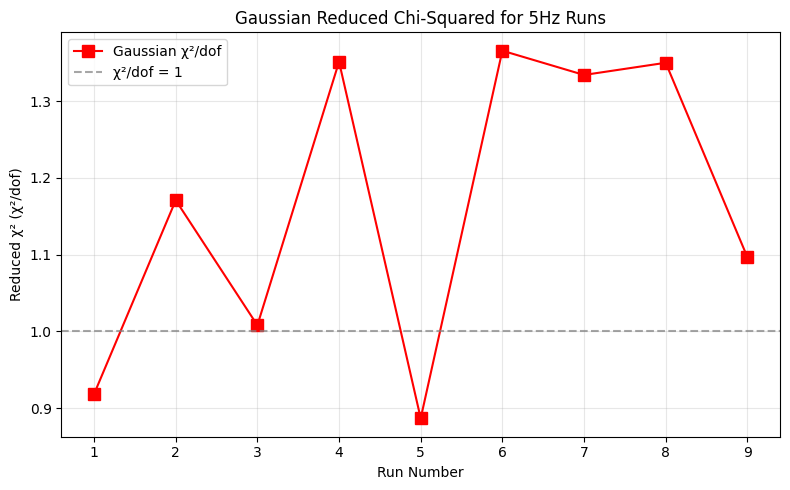

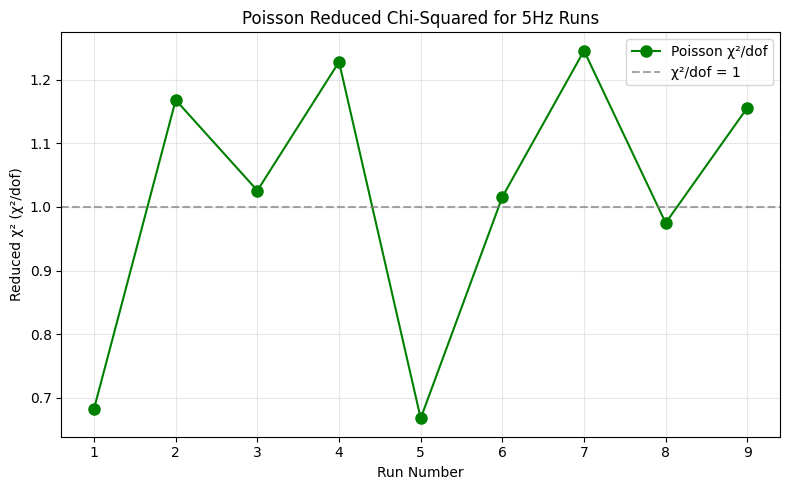

In [33]:
# Extract the sampling frequencies and chi²/dof values from 5Hz runs
some_more = [
    "5Hz_Run1.csv",
    "5Hz_Run2.csv",
    "5Hz_run3.csv",
    "5Hz_Run4.csv",
    "5Hz_Run5.csv",
    "5Hz_Run6.csv",
    "5Hz_Run7.csv",
    "5Hz_Run9.csv",
    "5Hz_Run10.csv",
]
run_num = list(range(1, len(some_more) + 1))  # Auto-generate run numbers based on list length

red_chi_g_list = []
red_chi_p_list = []

for filename in some_more:
    data_tmp = df(f"data_5hz/{filename}")[field_names[1]].to_numpy()
    
    mew_tmp = np.mean(data_tmp)
    sigma_tmp = np.std(data_tmp)
    
    x_min_tmp = int(np.min(data_tmp))
    x_max_tmp = int(np.max(data_tmp))
    
    x_tmp = np.arange(x_min_tmp, x_max_tmp + 1)
    
    obs_counts_tmp = np.array([np.sum(data_tmp == val) for val in x_tmp])
    
    exp_gauss_tmp = np.array([gausian(val, mew_tmp, sigma_tmp) for val in x_tmp])
    exp_gauss_tmp = exp_gauss_tmp / exp_gauss_tmp.sum() * obs_counts_tmp.sum()
    
    def poisson_safe_tmp(x_val, mu):
        return np.exp(x_val * np.log(mu) - mu - gammaln(x_val + 1))
    
    exp_pois_tmp = np.array([poisson_safe_tmp(val, mew_tmp) for val in x_tmp])
    exp_pois_tmp = exp_pois_tmp / exp_pois_tmp.sum() * obs_counts_tmp.sum()
    
    def merge_small_bins_tmp(obs, exp, min_exp=5):
        obs_m, exp_m = [], []
        o_acc, e_acc = 0, 0
        for o, e in zip(obs, exp):
            o_acc += o
            e_acc += e
            if e_acc >= min_exp:
                obs_m.append(o_acc)
                exp_m.append(e_acc)
                o_acc, e_acc = 0, 0
        if e_acc > 0:
            obs_m[-1] += o_acc
            exp_m[-1] += e_acc
        return np.array(obs_m), np.array(exp_m)
    
    obs_g_tmp, exp_g_tmp = merge_small_bins_tmp(obs_counts_tmp, exp_gauss_tmp)
    obs_p_tmp, exp_p_tmp = merge_small_bins_tmp(obs_counts_tmp, exp_pois_tmp)
    
    chi_g_tmp = chisquare(obs_g_tmp, f_exp=exp_g_tmp, ddof=2)
    chi_p_tmp = chisquare(obs_p_tmp, f_exp=exp_p_tmp, ddof=1)
    
    dof_g_tmp = len(obs_g_tmp) - 1 - 2
    dof_p_tmp = len(obs_p_tmp) - 1 - 1
    
    red_chi_g_list.append(chi_g_tmp.statistic / dof_g_tmp if dof_g_tmp > 0 else float('inf'))
    red_chi_p_list.append(chi_p_tmp.statistic / dof_p_tmp if dof_p_tmp > 0 else float('inf'))

# Plot 1: Gaussian chi²/dof
fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(run_num, red_chi_g_list, 'rs-', markersize=8, label="Gaussian χ²/dof")
ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.7, label="χ²/dof = 1")
ax1.set_xlabel("Run Number")
ax1.set_ylabel("Reduced χ² (χ²/dof)")
ax1.set_title("Gaussian Reduced Chi-Squared for 5Hz Runs")
ax1.grid(alpha=0.3)
ax1.legend()
plt.tight_layout()
plt.show()

# Plot 2: Poisson chi²/dof
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(run_num, red_chi_p_list, 'go-', markersize=8, label="Poisson χ²/dof")
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.7, label="χ²/dof = 1")
ax2.set_xlabel("Run Number")
ax2.set_ylabel("Reduced χ² (χ²/dof)")
ax2.set_title("Poisson Reduced Chi-Squared for 5Hz Runs")
ax2.grid(alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()

In [23]:
# Create a summary table of chi-squared results from 5Hz runs
summary_table = pd.DataFrame({
    "Run Number": run_num,
    "Gaussian χ²/dof": [f"{v:.3f}" for v in red_chi_g_list],
    "Poisson χ²/dof": [f"{v:.3f}" for v in red_chi_p_list],
})
print("Reduced Chi-Squared — 5Hz Runs Investigation")
print(summary_table.to_string(index=False))

Reduced Chi-Squared — 5Hz Runs Investigation
 Run Number Gaussian χ²/dof Poisson χ²/dof
          1           0.919          0.683
          2           1.171          1.168
          3           1.008          1.026
          4           1.351          1.228
          5           0.887          0.668
          6           1.366          1.016
          7           1.334          1.246
          8           1.350          0.975
          9           1.097          1.156


In [ ]:
from scipy.special import gammaln

#some_more = ["Data_5Hz_1min_2.5cm.csv","test_5Hz_1min.csv"]
some_more = [
    "5Hz_Run1.csv",
    "5Hz_Run2.csv",
    "5Hz_run3.csv",
    "5Hz_Run4.csv",
    "5Hz_Run5.csv",
    "5Hz_Run6.csv",
    "5Hz_Run7.csv",
    "5Hz_Run8.csv",
    "5Hz_Run9.csv",
    "5Hz_Run10.csv",
]
labels = ["run 1", "run 2", "run 3", "run 4", "run 5", "run 6", "run 7", "run 8", "run 9", "run 10"]
merge_small = True  # Set to False to disable merging of small bins

# Combine all data into one array
combined_data_list = []
for filename in some_more:
    d = df(f"data_5hz/{filename}")[field_names[1]].to_numpy()
    combined_data_list.append(d)
data = np.concatenate(combined_data_list)

# Subtract noise mean and propagate noise standard error
data_corrected = data - noise_mean
plt.figure()

mew = np.mean(data)
sigma = np.std(data)

# Propagate noise_se into the uncertainty of the mean
mew_corrected = mew - noise_mean
sigma_mew = np.sqrt((sigma / np.sqrt(len(data)))**2 + noise_se**2)

difference = -np.sqrt(mew) + sigma
difference_percent = (difference / mew) * 100
print(f"Combined: {difference_percent}%")
print(f"Combined - Mean: {mew:.4f} ± {sigma_mew:.4f} (incl. noise SE={noise_se:.4f})")
print(f"Combined - Corrected mean (noise subtracted): {mew_corrected:.4f} ± {sigma_mew:.4f}")

# Use integer bins for discrete data
x_min = int(np.min(data))
x_max = int(np.max(data))
bins = np.arange(x_min, x_max + 2) - 0.5  # center bins on integers

# Freedman-Diaconis rule for number of bins
data_iqr = np.subtract(*np.percentile(data, [75, 25]))
n = len(data)
if data_iqr > 0:
    bin_width_fd = 2 * data_iqr * n ** (-1/3)
    num_bins = max(4, int(np.ceil((data.max() - data.min()) / bin_width_fd)))
else:
    num_bins = 4

plt.hist(data, bins=num_bins, alpha=1, density=True, label="Histogram")

x = np.arange(x_min, x_max + 1)

# Gaussian plot
x_smooth = np.linspace(x_min, x_max, 200)
gauss_y_smooth = np.array([gausian(val, mew, sigma) for val in x_smooth])
plt.plot(x_smooth, gauss_y_smooth, 'r-', label="Gaussian (normalized)")

# Poisson plot - use log-space to avoid overflow with large values
def poisson_safe(x, mu):
    return np.exp(x * np.log(mu) - mu - gammaln(x + 1))

pois_y = np.array([poisson_safe(val, mew) for val in x])
plt.plot(x, pois_y, 'g--', label="Poisson (normalized)")

# Observed counts per integer value
obs_counts = np.array([np.sum(data == val) for val in x])

# Expected counts
exp_gauss = np.array([gausian(val, mew, sigma) for val in x])
exp_gauss = exp_gauss / exp_gauss.sum() * obs_counts.sum()

exp_pois = np.array([poisson_safe(val, mew) for val in x])
exp_pois = exp_pois / exp_pois.sum() * obs_counts.sum()

# Merge bins with expected < 5 (chi-square requirement)
def merge_small_bins(obs, exp, min_exp=5):
    obs_m, exp_m = [], []
    o_acc, e_acc = 0, 0
    for o, e in zip(obs, exp):
        o_acc += o
        e_acc += e
        if e_acc >= min_exp:
            obs_m.append(o_acc)
            exp_m.append(e_acc)
            o_acc, e_acc = 0, 0
    if e_acc > 0:
        obs_m[-1] += o_acc
        exp_m[-1] += e_acc
    return np.array(obs_m), np.array(exp_m)

if merge_small:
    obs_g, exp_g = merge_small_bins(obs_counts, exp_gauss)
    obs_p, exp_p = merge_small_bins(obs_counts, exp_pois)
else:
    obs_g, exp_g = obs_counts, exp_gauss
    obs_p, exp_p = obs_counts, exp_pois

# R^2 values
hist_vals = obs_counts / (obs_counts.sum())
gauss_fit_vals = exp_gauss / exp_gauss.sum()
pois_fit_vals = exp_pois / exp_pois.sum()

ss_tot = np.sum((hist_vals - np.mean(hist_vals)) ** 2)
r2 = 1 - np.sum((hist_vals - gauss_fit_vals) ** 2) / ss_tot
r2_pois = 1 - np.sum((hist_vals - pois_fit_vals) ** 2) / ss_tot
print(f"Combined - Gaussian fit R^2: {r2:.3f}")
print(f"Combined - Poisson fit R^2: {r2_pois:.3f}")

# ddof: 1 for Poisson (estimated mu), 2 for Gaussian (estimated mu, sigma)
chi_gaussian = chisquare(obs_g, f_exp=exp_g, ddof=2)
chi_poisson = chisquare(obs_p, f_exp=exp_p, ddof=1)

dof_g = len(obs_g) - 1 - 2  # number of bins - 1 - estimated params
dof_p = len(obs_p) - 1 - 1
red_chi_g = chi_gaussian.statistic / dof_g if dof_g > 0 else float('inf')
red_chi_p = chi_poisson.statistic / dof_p if dof_p > 0 else float('inf')

print(f"Combined - Chi-square Gaussian: stat={chi_gaussian.statistic:.3f}, dof={dof_g}, p={chi_gaussian.pvalue:.3f}, χ²/dof={red_chi_g:.3f}")
print(f"Combined - Chi-square Poisson: stat={chi_poisson.statistic:.3f}, dof={dof_p}, p={chi_poisson.pvalue:.3f}, χ²/dof={red_chi_p:.3f}")
print(f"Combined - Merge small bins: {'ON' if merge_small else 'OFF'}")
print(f"Combined - Number of histogram bins (Freedman-Diaconis): {num_bins}")
print(f"Combined - Better fit:", "Poisson" if chi_poisson.statistic < chi_gaussian.statistic else "Gaussian")

plt.title(f"Histogram with Poisson and Gaussian overlays for all runs combined")
plt.xlabel("Geiger Counts (counts/sample)")
plt.ylabel("Density")
plt.grid()

# Update legend labels with chi²/dof values
ax = plt.gca()
handles, labels_list = ax.get_legend_handles_labels()
new_labels = []
for lbl in labels_list:
    if lbl == "Gaussian (normalized)":
        new_labels.append(f"Gaussian (χ²/dof={red_chi_g:.3f})")
    elif lbl == "Poisson (normalized)":
        new_labels.append(f"Poisson (χ²/dof={red_chi_p:.3f})")
    else:
        new_labels.append(lbl)
plt.legend(handles, new_labels)
plt.show()

'from scipy.stats import chi2 as chi2_dist\n\n#some_more = ["Data_5Hz_1min_2.5cm.csv"]\nsome_more = [\n    "5Hz_Run1.csv",\n    "5Hz_Run2.csv",\n    "5Hz_run3.csv",\n    "5Hz_Run4.csv",\n    "5Hz_Run5.csv",\n    "5Hz_Run6.csv",\n    "5Hz_Run7.csv",\n    "5Hz_Run9.csv",\n    "5Hz_Run10.csv",\n]\n\nnum_bins = 20 # Change this value to adjust the number of bins\nmerge_small = False  # Set to False to disable merging of small bins\n\nfor filename in some_more:\n    data = df(f"data_5hz/{filename}")[field_names[1]].to_numpy()\n    quarter_len = len(data)\n    data = data[:quarter_len]\n    plt.figure()\n\n    mew = np.mean(data)\n    sigma = np.std(data)\n\n    difference = -np.sqrt(mew) + sigma\n    difference_percent = (difference / mew) * 100\n    print(f"{difference_percent}%")\n\n    # Use integer bins for discrete data\n    x_min = int(np.min(data))\n    x_max = int(np.max(data))\n    bins = np.arange(x_min, x_max + 2) - 0.5  # center bins on integers\n\n    plt.hist(data, bins=num_bi

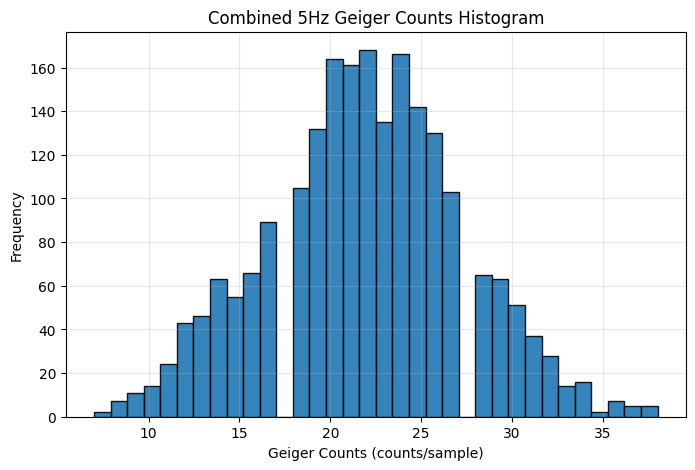

Loaded 9 files, total samples: 2119
Mean: 21.916, Std: 5.365


26.5cm: 3.3879103003851303%
26.5cm - Mean: 2.9355 ± 0.3323 (incl. noise SE=0.0665)
26.5cm - Corrected mean (noise subtracted): 2.5466 ± 0.3323
26.5cm - Gaussian fit R^2: 0.712
26.5cm - Poisson fit R^2: 0.556
26.5cm - Chi-square Gaussian: stat=2.549, dof=2, p=0.280, χ²/dof=1.275
26.5cm - Chi-square Poisson: stat=3.515, dof=3, p=0.319, χ²/dof=1.172
26.5cm - Merge small bins: ON
26.5cm - Number of histogram bins (Freedman-Diaconis): 7
26.5cm - Better fit: Gaussian


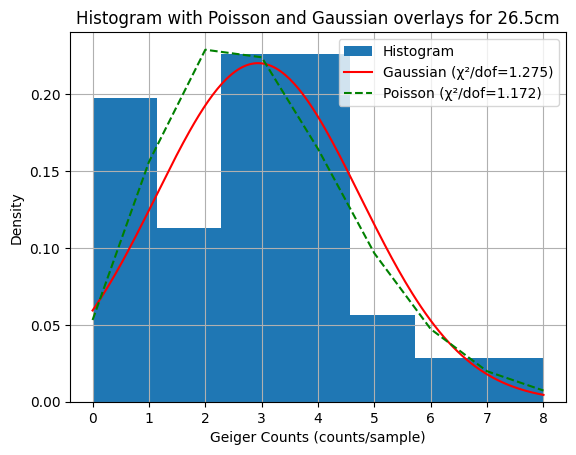

20.5cm: -3.3495746195382052%
20.5cm - Mean: 3.3667 ± 0.3214 (incl. noise SE=0.0665)
20.5cm - Corrected mean (noise subtracted): 2.9778 ± 0.3214
20.5cm - Gaussian fit R^2: 0.700
20.5cm - Poisson fit R^2: 0.764
20.5cm - Chi-square Gaussian: stat=0.919, dof=1, p=0.338, χ²/dof=0.919
20.5cm - Chi-square Poisson: stat=0.122, dof=2, p=0.941, χ²/dof=0.061
20.5cm - Merge small bins: ON
20.5cm - Number of histogram bins (Freedman-Diaconis): 7
20.5cm - Better fit: Poisson


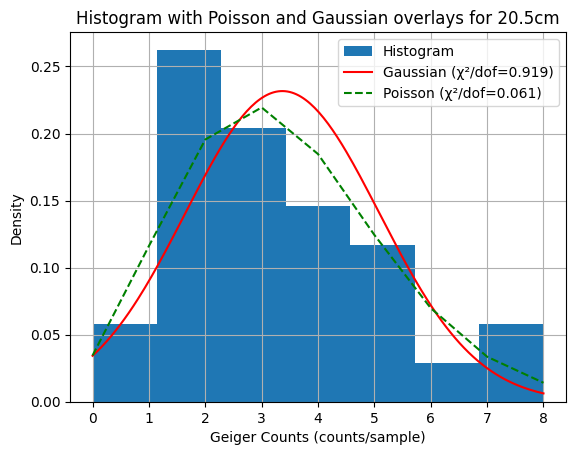

14.5cm: -0.23854214043095406%
14.5cm - Mean: 4.4706 ± 0.3669 (incl. noise SE=0.0665)
14.5cm - Corrected mean (noise subtracted): 4.0817 ± 0.3669
14.5cm - Gaussian fit R^2: 0.760
14.5cm - Poisson fit R^2: 0.768
14.5cm - Chi-square Gaussian: stat=1.358, dof=3, p=0.715, χ²/dof=0.453
14.5cm - Chi-square Poisson: stat=0.355, dof=3, p=0.949, χ²/dof=0.118
14.5cm - Merge small bins: ON
14.5cm - Number of histogram bins (Freedman-Diaconis): 5
14.5cm - Better fit: Poisson


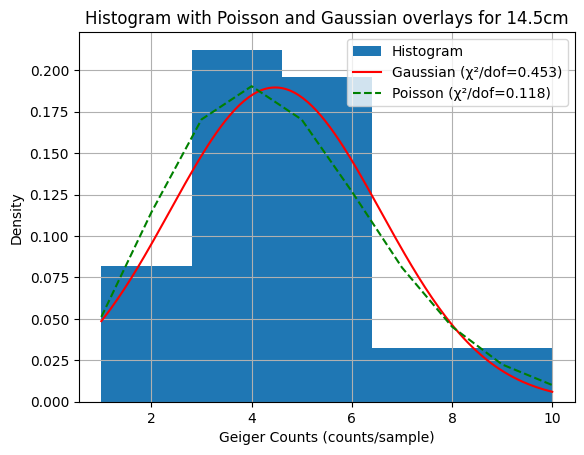

8.5cm: -3.1157336001576263%
8.5cm - Mean: 7.3548 ± 0.4509 (incl. noise SE=0.0665)
8.5cm - Corrected mean (noise subtracted): 6.9659 ± 0.4509
8.5cm - Gaussian fit R^2: 0.652
8.5cm - Poisson fit R^2: 0.639
8.5cm - Chi-square Gaussian: stat=0.512, dof=1, p=0.474, χ²/dof=0.512
8.5cm - Chi-square Poisson: stat=0.707, dof=2, p=0.702, χ²/dof=0.353
8.5cm - Merge small bins: ON
8.5cm - Number of histogram bins (Freedman-Diaconis): 7
8.5cm - Better fit: Gaussian


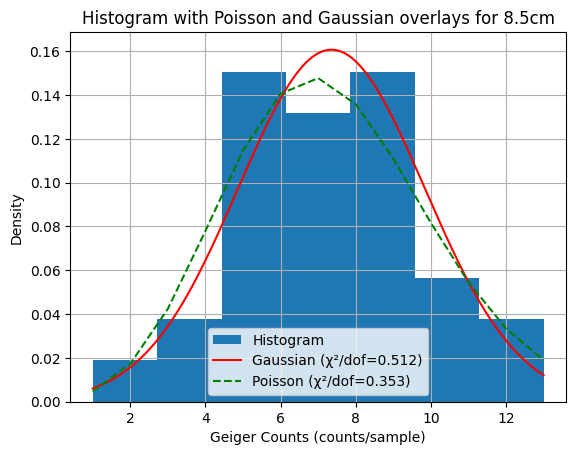

2.5cm: -2.819181742914015%
2.5cm - Mean: 55.9355 ± 1.0621 (incl. noise SE=0.0665)
2.5cm - Corrected mean (noise subtracted): 55.5466 ± 1.0621
2.5cm - Gaussian fit R^2: 0.396
2.5cm - Poisson fit R^2: 0.327
2.5cm - Chi-square Gaussian: stat=1.500, dof=2, p=0.472, χ²/dof=0.750
2.5cm - Chi-square Poisson: stat=4.547, dof=3, p=0.208, χ²/dof=1.516
2.5cm - Merge small bins: ON
2.5cm - Number of histogram bins (Freedman-Diaconis): 8
2.5cm - Better fit: Gaussian


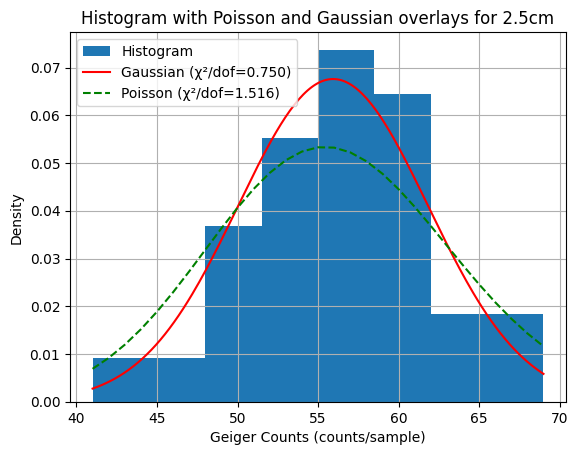

0cm: -0.18669118178150954%
0cm - Mean: 126.7333 ± 2.0132 (incl. noise SE=0.0665)
0cm - Corrected mean (noise subtracted): 126.3444 ± 2.0132
0cm - Gaussian fit R^2: 0.141
0cm - Poisson fit R^2: 0.142
0cm - Chi-square Gaussian: stat=2.445, dof=2, p=0.294, χ²/dof=1.223
0cm - Chi-square Poisson: stat=2.453, dof=3, p=0.484, χ²/dof=0.818
0cm - Merge small bins: ON
0cm - Number of histogram bins (Freedman-Diaconis): 6
0cm - Better fit: Gaussian


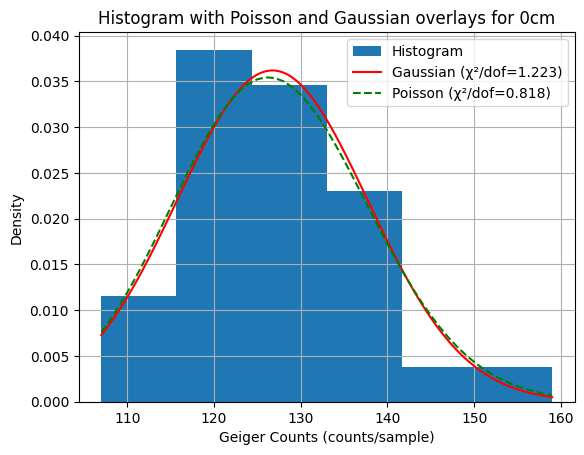

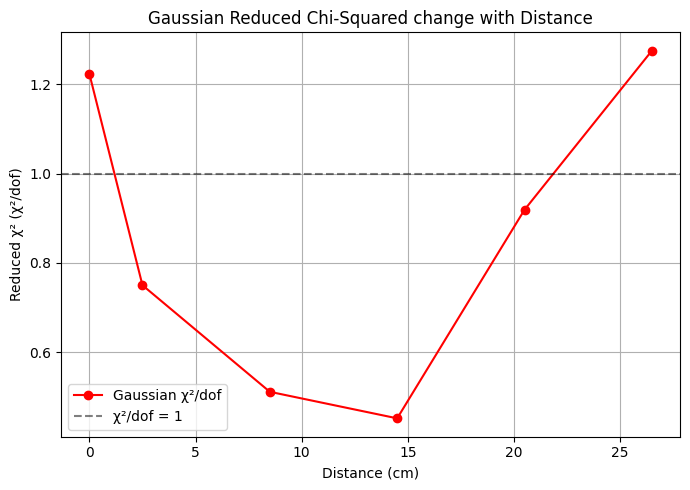

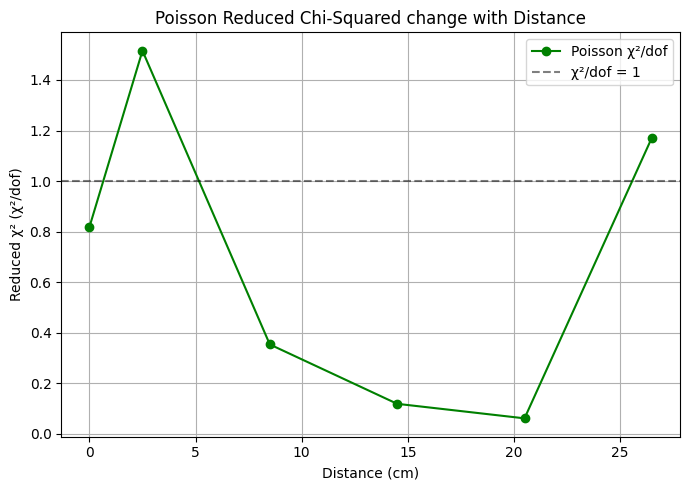

In [ ]:
from scipy.special import gammaln

#some_more = ["Data_5Hz_1min_2.5cm.csv","test_5Hz_1min.csv"]
some_more = ["Distance_26.5cm.csv", "Distance_20.5cm.csv", "Distance_14.5cm.csv", "Distance_8.5cm.csv", "Distance_2.5cm.csv", "Distance_0cm.csv"]
labels = ["26.5cm", "20.5cm", "14.5cm", "8.5cm", "2.5cm", "0cm"]
merge_small = True  # Set to False to disable merging of small bins

red_chi_g_dist = []
red_chi_p_dist = []
dist_values = [26.5, 20.5, 14.5, 8.5, 2.5, 0]

for filename, label in zip(some_more, labels):
    data = df(f"length_data/{filename}")[field_names[1]].to_numpy()
    quarter_len = len(data)
    data = data[:quarter_len]
    
    # Subtract noise mean and propagate noise standard error
    data_corrected = data - noise_mean
    plt.figure()
    
    mew = np.mean(data)
    sigma = np.std(data)
    
    # Propagate noise_se into the uncertainty of the mean
    mew_corrected = mew - noise_mean
    sigma_mew = np.sqrt((sigma / np.sqrt(len(data)))**2 + noise_se**2)
    
    difference = -np.sqrt(mew) + sigma
    difference_percent = (difference / mew) * 100
    print(f"{label}: {difference_percent}%")
    print(f"{label} - Mean: {mew:.4f} ± {sigma_mew:.4f} (incl. noise SE={noise_se:.4f})")
    print(f"{label} - Corrected mean (noise subtracted): {mew_corrected:.4f} ± {sigma_mew:.4f}")
    
    # Use integer bins for discrete data
    x_min = int(np.min(data))
    x_max = int(np.max(data))
    bins = np.arange(x_min, x_max + 2) - 0.5  # center bins on integers
    
    # Freedman-Diaconis rule for number of bins
    data_iqr = np.subtract(*np.percentile(data, [75, 25]))
    n = len(data)
    if data_iqr > 0:
        bin_width_fd = 2 * data_iqr * n ** (-1/3)
        num_bins = max(4, int(np.ceil((data.max() - data.min()) / bin_width_fd)))
    else:
        num_bins = 4
    
    plt.hist(data, bins=num_bins, alpha=1, density=True, label="Histogram")
    
    x = np.arange(x_min, x_max + 1)

    # Gaussian plot
    x_smooth = np.linspace(x_min, x_max, 200)
    gauss_y_smooth = np.array([gausian(val, mew, sigma) for val in x_smooth])
    plt.plot(x_smooth, gauss_y_smooth, 'r-', label="Gaussian (normalized)")
    
    # Poisson plot - use log-space to avoid overflow with large values
    def poisson_safe(x, mu):
        return np.exp(x * np.log(mu) - mu - gammaln(x + 1))
    
    pois_y = np.array([poisson_safe(val, mew) for val in x])
    plt.plot(x, pois_y, 'g--', label="Poisson (normalized)")
    
    # Observed counts per integer value
    obs_counts = np.array([np.sum(data == val) for val in x])
    
    # Expected counts
    exp_gauss = np.array([gausian(val, mew, sigma) for val in x])
    exp_gauss = exp_gauss / exp_gauss.sum() * obs_counts.sum()
    
    exp_pois = np.array([poisson_safe(val, mew) for val in x])
    exp_pois = exp_pois / exp_pois.sum() * obs_counts.sum()
    
    # Merge bins with expected < 5 (chi-square requirement)
    def merge_small_bins(obs, exp, min_exp=5):
        obs_m, exp_m = [], []
        o_acc, e_acc = 0, 0
        for o, e in zip(obs, exp):
            o_acc += o
            e_acc += e
            if e_acc >= min_exp:
                obs_m.append(o_acc)
                exp_m.append(e_acc)
                o_acc, e_acc = 0, 0
        if e_acc > 0:
            obs_m[-1] += o_acc
            exp_m[-1] += e_acc
        return np.array(obs_m), np.array(exp_m)
    
    if merge_small:
        obs_g, exp_g = merge_small_bins(obs_counts, exp_gauss)
        obs_p, exp_p = merge_small_bins(obs_counts, exp_pois)
    else:
        obs_g, exp_g = obs_counts, exp_gauss
        obs_p, exp_p = obs_counts, exp_pois
    
    # R^2 values
    hist_vals = obs_counts / (obs_counts.sum())
    gauss_fit_vals = exp_gauss / exp_gauss.sum()
    pois_fit_vals = exp_pois / exp_pois.sum()
    
    ss_tot = np.sum((hist_vals - np.mean(hist_vals)) ** 2)
    r2 = 1 - np.sum((hist_vals - gauss_fit_vals) ** 2) / ss_tot
    r2_pois = 1 - np.sum((hist_vals - pois_fit_vals) ** 2) / ss_tot
    print(f"{label} - Gaussian fit R^2: {r2:.3f}")
    print(f"{label} - Poisson fit R^2: {r2_pois:.3f}")
    
    # ddof: 1 for Poisson (estimated mu), 2 for Gaussian (estimated mu, sigma)
    chi_gaussian = chisquare(obs_g, f_exp=exp_g, ddof=2)
    chi_poisson = chisquare(obs_p, f_exp=exp_p, ddof=1)
    
    dof_g = len(obs_g) - 1 - 2  # number of bins - 1 - estimated params
    dof_p = len(obs_p) - 1 - 1
    red_chi_g = chi_gaussian.statistic / dof_g if dof_g > 0 else float('inf')
    red_chi_p = chi_poisson.statistic / dof_p if dof_p > 0 else float('inf')
    
    red_chi_g_dist.append(red_chi_g)
    red_chi_p_dist.append(red_chi_p)
    
    print(f"{label} - Chi-square Gaussian: stat={chi_gaussian.statistic:.3f}, dof={dof_g}, p={chi_gaussian.pvalue:.3f}, χ²/dof={red_chi_g:.3f}")
    print(f"{label} - Chi-square Poisson: stat={chi_poisson.statistic:.3f}, dof={dof_p}, p={chi_poisson.pvalue:.3f}, χ²/dof={red_chi_p:.3f}")
    print(f"{label} - Merge small bins: {'ON' if merge_small else 'OFF'}")
    print(f"{label} - Number of histogram bins (Freedman-Diaconis): {num_bins}")
    print(f"{label} - Better fit:", "Poisson" if chi_poisson.statistic < chi_gaussian.statistic else "Gaussian")
    
    plt.title(f"Histogram with Poisson and Gaussian overlays for {label}")
    plt.xlabel("Geiger Counts (counts/sample)")
    plt.ylabel("Density")
    plt.grid()
    
    # Update legend labels with chi²/dof values
    ax = plt.gca()
    handles, labels_list = ax.get_legend_handles_labels()
    new_labels = []
    for lbl in labels_list:
        if lbl == "Gaussian (normalized)":
            new_labels.append(f"Gaussian (χ²/dof={red_chi_g:.3f})")
        elif lbl == "Poisson (normalized)":
            new_labels.append(f"Poisson (χ²/dof={red_chi_p:.3f})")
        else:
            new_labels.append(lbl)
    plt.legend(handles, new_labels)
    plt.show()

# Summary plot: reduced chi-squared vs distance (Gaussian)
fig1, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(dist_values, red_chi_g_dist, 'ro-', label="Gaussian χ²/dof")
ax1.axhline(y=1, color='k', linestyle='--', alpha=0.5, label="χ²/dof = 1")
ax1.set_xlabel("Distance (cm)")
ax1.set_ylabel("Reduced χ² (χ²/dof)")
ax1.set_title("Gaussian Reduced Chi-Squared change with Distance")
ax1.legend()
ax1.grid()
plt.tight_layout()
plt.show()

# Summary plot: reduced chi-squared vs distance (Poisson)
fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.plot(dist_values, red_chi_p_dist, 'go-', label="Poisson χ²/dof")
ax2.axhline(y=1, color='k', linestyle='--', alpha=0.5, label="χ²/dof = 1")
ax2.set_xlabel("Distance (cm)")
ax2.set_ylabel("Reduced χ² (χ²/dof)")
ax2.set_title("Poisson Reduced Chi-Squared change with Distance")
ax2.legend()
ax2.grid()
plt.tight_layout()
plt.show()

In [ ]:
# Table 1: Reduced chi-squared values for distance (length) investigation
dist_table = pd.DataFrame({
    "Distance (cm)": dist_values,
    "Gaussian χ²/dof": [f"{v:.3f}" for v in red_chi_g_dist],
    "Poisson χ²/dof": [f"{v:.3f}" for v in red_chi_p_dist],
})
print("Reduced Chi-Squared — Distance Investigation")
print(dist_table.to_string(index=False))
print()

# Table 2: Reduced chi-squared values for sampling rate investigation
hz_labels = ["1 Hz", "5 Hz", "10 Hz", "25 Hz", "40 Hz", "50 Hz"]
rate_table = pd.DataFrame({
    "Sampling Rate": hz_labels,
    "Gaussian χ²/dof": [f"{v:.3f}" for v in red_chi_g_list],
    "Poisson χ²/dof": [f"{v:.3f}" for v in red_chi_p_list],
})
print("Reduced Chi-Squared — Sampling Rate Investigation")
print(rate_table.to_string(index=False))

Reduced Chi-Squared — Distance Investigation
 Distance (cm) Gaussian χ²/dof Poisson χ²/dof
          26.5           1.275          1.172
          20.5           0.919          0.061
          14.5           0.453          0.118
           8.5           0.512          0.353
           2.5           0.750          1.516
           0.0           1.223          0.818

Reduced Chi-Squared — Sampling Rate Investigation
Sampling Rate Gaussian χ²/dof Poisson χ²/dof
         1 Hz           1.908          1.092
         5 Hz           0.919          0.683
        10 Hz           1.864          1.093
        25 Hz           7.794          1.262
        40 Hz          24.958          0.850
        50 Hz          43.838          1.158


In [ ]:
print(0.000000000001**0.0000000000001)

0.9999999999972369
